<a href="https://colab.research.google.com/github/Aasrith123403/AasrithBranch/blob/aasrithBranch/ResearchPaperCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kruskal, linregress, pearsonr
import re
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

In [2]:
fname = 'student_lifestyle_dataset.csv'
df = pd.read_csv(fname)

/tmp/ipykernel_4929/577889096.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stress_counts.index, y=stress_counts.values, palette='viridis')


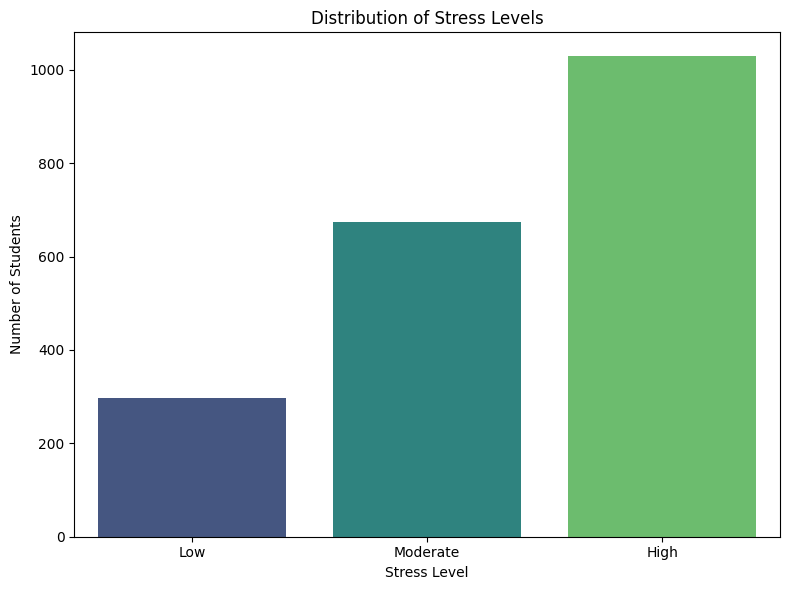

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

stress_order = ['Low', 'Moderate', 'High']
stress_counts = df['Stress_Level'].value_counts().reindex(stress_order)

plt.figure(figsize=(8, 6))
sns.barplot(x=stress_counts.index, y=stress_counts.values, palette='viridis')
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

In [4]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [5]:
df.columns

Index(['Student_ID', 'Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
       'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
       'Physical_Activity_Hours_Per_Day', 'GPA', 'Stress_Level'],
      dtype='object')

In [6]:

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import font_manager
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")


INK      = "#1f2933"   # near-black text
SUBTLE   = "#6b7280"   # gray secondary
GRID     = "#e5e7eb"   # light grid
POINT    = "#4c72b0"   # muted blue points
FIT      = "#c44e52"   # warm red fit line
DIAG     = "#9aa5b1"   # diagonal reference
LOW      = "#55a868"   # green
MOD      = "#dd8452"   # orange
HIGH     = "#c44e52"   # red
STRESS_C = {"Low": LOW, "Moderate": MOD, "High": HIGH}
BAR_GRAD = ["#a8c4e0", "#7aa3cf", "#4c72b0", "#37588c", "#243b66"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "axes.labelcolor": INK,
    "axes.edgecolor": "#cbd2d9",
    "axes.linewidth": 0.8,
    "text.color": INK,
    "xtick.color": SUBTLE,
    "ytick.color": SUBTLE,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "axes.titlepad": 8,
})

def style(ax):
    """Clean spines + soft horizontal grid."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd2d9")
    ax.spines["bottom"].set_color("#cbd2d9")
    ax.grid(axis="y", color=GRID, lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


CSV_PATH = "student_lifestyle_dataset.csv"
df = pd.read_csv(CSV_PATH)
df["Stress_code"] = df["Stress_Level"].map({"Low":0,"Moderate":1,"High":2})
habitcols=["Study_Hours_Per_Day","Sleep_Hours_Per_Day","Social_Hours_Per_Day",
           "Extracurricular_Hours_Per_Day","Physical_Activity_Hours_Per_Day"]
labels=["Study","Sleep","Social","Extracurricular","Physical activity"]
allcols=habitcols+["Stress_code"]
order=[("Low",0),("Moderate",1),("High",2)]
names=["Low","Moderate","High"]
r2s={0:0.066,1:0.173,2:0.469}

def scat(ax,x,y,xl,r,annotate_r=True):
    ax.scatter(x,y,s=10,alpha=0.30,color=POINT,edgecolors="none",zorder=2,rasterized=True)
    m,b=np.polyfit(x,y,1); xs=np.linspace(x.min(),x.max(),60)
    ax.plot(xs,m*xs+b,color=FIT,lw=2,zorder=3,solid_capstyle="round")
    style(ax)
    ax.set_xlabel(xl,fontsize=8)
    if annotate_r:
        ax.text(0.04,0.93,f"r = {r:+.3f}",transform=ax.transAxes,
                fontsize=8,fontweight="bold",va="top",ha="left",
                bbox=dict(boxstyle="round,pad=0.3",fc="white",ec="#cbd2d9",lw=0.6,alpha=0.9))

# ================================================================ FIG 1
fig,ax=plt.subplots(figsize=(5.2,3.4))
counts=df["Stress_Level"].value_counts().reindex(names)
bars=ax.bar(counts.index,counts.values,
            color=[STRESS_C[n] for n in names],width=0.62,zorder=3,edgecolor="white",lw=1.2)
for i,v in enumerate(counts.values):
    ax.text(i,v+12,f"{v}\n{v/len(df)*100:.1f}%",ha="center",va="bottom",
            fontsize=9,fontweight="bold",color=INK)
style(ax)
ax.set_ylabel("Number of students")
ax.set_title("Distribution of Stress Levels",loc="left")
ax.set_ylim(0,counts.max()*1.18)
ax.margins(x=0.08)
plt.tight_layout(); plt.savefig("fig1_stressdist.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 2
fig,axes=plt.subplots(2,3,figsize=(9.2,5.6))
for i,(c,l) in enumerate(zip(habitcols,labels)):
    r=np.corrcoef(df[c],df["GPA"])[0,1]
    ax=axes.flat[i]; scat(ax,df[c],df["GPA"],l+" (hours/day)",r)
    ax.set_title(l,loc="left",fontsize=10)
    if i%3==0: ax.set_ylabel("GPA")
axes.flat[5].axis("off")
plt.tight_layout(rect=[0,0,1,0.90])
fig.suptitle("Lifestyle Habits vs GPA",x=0.012,y=0.99,ha="left",fontsize=13,fontweight="bold")
plt.savefig("fig2_habits_gpa.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 3
def box(ax,data,ylabel,title):
    bp=ax.boxplot(data,tick_labels=names,showmeans=True,patch_artist=True,widths=0.55,
                  medianprops=dict(color=INK,lw=1.6),
                  whiskerprops=dict(color="#9aa5b1",lw=1.1),
                  capprops=dict(color="#9aa5b1",lw=1.1),
                  flierprops=dict(marker="o",ms=2.5,mfc="#cbd2d9",mec="none",alpha=0.5),
                  meanprops=dict(marker="^",mfc="white",mec=INK,ms=6,mew=1.2))
    for patch,n in zip(bp["boxes"],names):
        patch.set_facecolor(STRESS_C[n]); patch.set_alpha(0.55); patch.set_edgecolor(STRESS_C[n]); patch.set_linewidth(1.2)
    style(ax); ax.set_ylabel(ylabel,fontsize=8); ax.set_title(title,loc="left",fontsize=9.5)

fig,axes=plt.subplots(2,3,figsize=(9.2,5.6))
box(axes.flat[0],[df[df["Stress_Level"]==s]["GPA"] for s in names],"GPA","GPA  (\u03c1 = +0.555)")
for i,(c,l) in enumerate(zip(habitcols,labels),start=1):
    box(axes.flat[i],[df[df["Stress_Level"]==s][c] for s in names],"hours/day",l)
plt.tight_layout(rect=[0,0,1,0.90])
fig.suptitle("GPA and Habits by Stress Level",x=0.012,y=0.99,ha="left",fontsize=13,fontweight="bold")
plt.savefig("fig3_bystress.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 4
lr=LinearRegression().fit(df[allcols],df["GPA"]); pred=lr.predict(df[allcols]); resid=df["GPA"]-pred
fig,axes=plt.subplots(1,2,figsize=(9.2,3.9))
ax=axes[0]
ax.scatter(df["GPA"],pred,s=10,alpha=0.30,color=POINT,edgecolors="none",rasterized=True,zorder=2)
lims=[df["GPA"].min(),df["GPA"].max()]; ax.plot(lims,lims,"--",color=DIAG,lw=1.6,zorder=3)
style(ax); ax.set_xlabel("Actual GPA"); ax.set_ylabel("Predicted GPA")
ax.set_title("Predicted vs Actual",loc="left")
ax.text(0.04,0.93,"R\u00b2 = 0.541",transform=ax.transAxes,fontsize=8.5,fontweight="bold",va="top",
        bbox=dict(boxstyle="round,pad=0.3",fc="white",ec="#cbd2d9",lw=0.6,alpha=0.9))
ax=axes[1]
ax.scatter(pred,resid,s=10,alpha=0.30,color=POINT,edgecolors="none",rasterized=True,zorder=2)
ax.axhline(0,color=FIT,lw=1.6,ls="--",zorder=3)
style(ax); ax.set_xlabel("Fitted GPA"); ax.set_ylabel("Residual")
ax.set_title("Residuals vs Fitted",loc="left")
plt.tight_layout(rect=[0,0,1,0.91])
fig.suptitle("Multiple Regression Diagnostics",x=0.012,y=0.99,ha="left",fontsize=13,fontweight="bold")
plt.savefig("fig4_diagnostics.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 5
fig,axes=plt.subplots(3,5,figsize=(10.0,6.0),sharey="row")
for ri,(sname,scode) in enumerate(order):
    sub=df[df["Stress_code"]==scode]
    for ci,(c,l) in enumerate(zip(habitcols,labels)):
        ax=axes[ri,ci]
        ax.scatter(sub[c],sub["GPA"],s=7,alpha=0.30,color=POINT,edgecolors="none",rasterized=True,zorder=2)
        m,b=np.polyfit(sub[c],sub["GPA"],1); xs=np.linspace(sub[c].min(),sub[c].max(),40)
        ax.plot(xs,m*xs+b,color=STRESS_C[sname],lw=2,zorder=3,solid_capstyle="round")
        style(ax); ax.tick_params(labelsize=6.5)
        if ri==0: ax.set_title(l,fontsize=9)
        if ri==2: ax.set_xlabel("hours/day",fontsize=7.5)
        if ci==0:
            ax.set_ylabel("GPA",fontsize=8)
            ax.annotate(f"{sname} stress\nR\u00b2 = {r2s[scode]:.3f}",xy=(-0.55,0.5),
                        xycoords="axes fraction",ha="center",va="center",rotation=90,
                        fontsize=9,fontweight="bold",color=STRESS_C[sname])
plt.tight_layout(rect=[0.03,0,1,0.90])
fig.suptitle("Habit\u2013GPA Relationships, Stratified by Stress Level",x=0.012,y=0.99,ha="left",fontsize=13,fontweight="bold")
plt.savefig("fig5_strat_grid.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 6
fig,axes=plt.subplots(1,3,figsize=(9.6,3.4),sharey=True)
for i,(sname,scode) in enumerate(order):
    sub=df[df["Stress_code"]==scode]
    lr2=LinearRegression().fit(sub[habitcols],sub["GPA"]); p2=lr2.predict(sub[habitcols])
    ax=axes[i]
    ax.scatter(sub["GPA"],p2,s=12,alpha=0.35,color=STRESS_C[sname],edgecolors="none",rasterized=True,zorder=2)
    lims=[sub["GPA"].min(),sub["GPA"].max()]; ax.plot(lims,lims,"--",color=DIAG,lw=1.5,zorder=3)
    style(ax); ax.set_xlabel("Actual GPA")
    if i==0: ax.set_ylabel("Predicted GPA")
    ax.set_title(f"{sname} stress",loc="left",color=STRESS_C[sname])
    ax.text(0.04,0.93,f"R\u00b2 = {r2s[scode]:.3f}",transform=ax.transAxes,fontsize=8,fontweight="bold",va="top",
            bbox=dict(boxstyle="round,pad=0.3",fc="white",ec="#cbd2d9",lw=0.6,alpha=0.9))
plt.tight_layout(rect=[0,0,1,0.89])
fig.suptitle("Predicted vs Actual GPA by Stress Group",x=0.012,y=0.99,ha="left",fontsize=13,fontweight="bold")
plt.savefig("fig6_pred_bystress.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 7
fig,axes=plt.subplots(1,3,figsize=(9.6,3.4),sharey=True)
for i,(sname,scode) in enumerate(order):
    sub=df[df["Stress_code"]==scode]
    lr2=LinearRegression().fit(sub[habitcols],sub["GPA"]); p2=lr2.predict(sub[habitcols]); res2=sub["GPA"]-p2
    ax=axes[i]
    ax.scatter(p2,res2,s=12,alpha=0.35,color=STRESS_C[sname],edgecolors="none",rasterized=True,zorder=2)
    ax.axhline(0,color=INK,lw=1.3,ls="--",zorder=3)
    style(ax); ax.set_xlabel("Fitted GPA")
    if i==0: ax.set_ylabel("Residual")
    ax.set_title(f"{sname} stress",loc="left",color=STRESS_C[sname])
plt.tight_layout(rect=[0,0,1,0.89])
fig.suptitle("Residuals vs Fitted by Stress Group",x=0.012,y=0.99,ha="left",fontsize=13,fontweight="bold")
plt.savefig("fig7_resid_bystress.png",bbox_inches="tight"); plt.close()

# ================================================================ FIG 8
X=df[habitcols]; y=df["Stress_Level"]
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
pipe=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000)); pipe.fit(Xtr,ytr)
pi=permutation_importance(pipe,Xte,yte,n_repeats=30,random_state=42)
ord_idx=np.argsort(pi.importances_mean)
fig,ax=plt.subplots(figsize=(6.2,3.6))
ypos=np.arange(len(ord_idx))
ax.barh(ypos,pi.importances_mean[ord_idx],
        xerr=pi.importances_std[ord_idx],
        color=[BAR_GRAD[i] for i in range(len(ord_idx))],
        edgecolor="white",lw=1,zorder=3,
        error_kw=dict(ecolor=SUBTLE,lw=1,capsize=3))
ax.set_yticks(ypos); ax.set_yticklabels([labels[i] for i in ord_idx])
for i,idx in enumerate(ord_idx):
    v=pi.importances_mean[idx]
    ax.text(v+pi.importances_std[idx]+0.004,i,f"{v:.3f}",va="center",fontsize=8,fontweight="bold",color=INK)
style(ax); ax.grid(axis="y",lw=0); ax.grid(axis="x",color=GRID,lw=0.7)
ax.set_xlabel("Permutation importance (\u0394 accuracy)")
ax.set_title("Predictors of Stress Level",loc="left")
ax.set_xlim(0,max(pi.importances_mean)*1.25)
plt.tight_layout(); plt.savefig("fig8_permimp.png",bbox_inches="tight"); plt.close()

print("All 8 figures saved as PNGs in the current folder.")

All 8 figures saved as PNGs in the current folder.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
 8   Stress_code                      2000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 140.8+ KB


In [8]:
df.isnull().sum()

,0
Student_ID,0
Study_Hours_Per_Day,0
Extracurricular_Hours_Per_Day,0
Sleep_Hours_Per_Day,0
Social_Hours_Per_Day,0
Physical_Activity_Hours_Per_Day,0
GPA,0
Stress_Level,0
Stress_code,0


In [9]:
features = [
    'Study_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]
target = 'GPA'
stress_col = 'Stress_Level'

df = df[features + [stress_col, target]].dropna()


stress_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Code'] = df[stress_col].map(stress_map)


print("===== INDIVIDUAL CORRELATIONS =====")
corrs = {}
for f in features:
    r, p = pearsonr(df[f], df[target])
    corrs[f] = r
    print(f"{f}: r = {r:.3f}, p = {p:.4f}")


r_s, p_s = spearmanr(df['Stress_Code'], df[target])
corrs['Stress_Level'] = r_s
print(f"Stress_Level: r = {r_s:.3f}, p = {p_s:.4f}")


strongest = max(corrs, key=lambda k: abs(corrs[k]))
print(f"\nStrongest predictor of GPA (by |r|): {strongest} (r = {corrs[strongest]:.3f})")


X = df[features + ['Stress_Code']]
y = df[target]

model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)

print("\n===== MULTIPLE LINEAR REGRESSION RESULTS =====")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Model R² = {r2:.3f}")

print("\n===== INTERPRETATION =====")
print("Positive coefficients → higher GPA when that variable increases (holding others constant).")
print("Negative coefficients → lower GPA when that variable increases (holding others constant).")
print(f"Strongest correlation overall: {strongest}")



def scatter_with_fit(x, y, x_label, y_label="GPA", title=None):
    plt.figure()
    plt.scatter(x, y, alpha=0.6)
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(np.min(x), np.max(x), 200)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if title:
        plt.title(title)
    plt.show()


for f in features:
    scatter_with_fit(df[f].values, df[target].values,
                     x_label=f, title=f"{f} vs GPA (r = {corrs[f]:.3f})")


scatter_with_fit(df['Stress_Code'].values, df[target].values,
                 x_label="Stress_Level (ordinal: Low=0, Moderate=1, High=2)",
                 title=f"Stress Level vs GPA (Spearman r = {r_s:.3f})")



y_pred = model.predict(X)
plt.figure()
plt.scatter(y, y_pred, alpha=0.6)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
plt.plot(lims, lims)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Predicted vs Actual GPA (Multiple Linear Regression)")
plt.show()


residuals = y - y_pred
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted (Predicted GPA)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Multiple Linear Regression)")
plt.show()


===== INDIVIDUAL CORRELATIONS =====
Study_Hours_Per_Day: r = 0.734, p = 0.0000
Sleep_Hours_Per_Day: r = -0.004, p = 0.8484
Social_Hours_Per_Day: r = -0.086, p = 0.0001
Extracurricular_Hours_Per_Day: r = -0.032, p = 0.1503
Physical_Activity_Hours_Per_Day: r = -0.341, p = 0.0000
Stress_Level: r = 0.555, p = 0.0000

Strongest predictor of GPA (by |r|): Study_Hours_Per_Day (r = 0.734)

===== MULTIPLE LINEAR REGRESSION RESULTS =====
Study_Hours_Per_Day: 0.126
Sleep_Hours_Per_Day: -0.033
Social_Hours_Per_Day: -0.027
Extracurricular_Hours_Per_Day: -0.036
Physical_Activity_Hours_Per_Day: -0.029
Stress_Code: 0.000
Intercept: 2.697
Model R² = 0.541

===== INTERPRETATION =====
Positive coefficients → higher GPA when that variable increases (holding others constant).
Negative coefficients → lower GPA when that variable increases (holding others constant).
Strongest correlation overall: Study_Hours_Per_Day


In [10]:
features = [
    'Study_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]
target = 'GPA'
stress_col = 'Stress_Level'
stress_order = ['Low', 'Moderate', 'High']


df = df[features + [stress_col, target]].dropna()


groups_all = {name: g.copy() for name, g in df.groupby(stress_col)}
ordered_groups = [(s, groups_all[s]) for s in stress_order if s in groups_all]

print("===== SAMPLE SIZES BY STRESS LEVEL =====")
for name, g in ordered_groups:
    print(f"{name}: n = {len(g)}")
print()


print("===== MULTIPLE LINEAR REGRESSION BY STRESS LEVEL =====")
models = {}
for name, g in ordered_groups:
    X = g[features].values
    y = g[target].values
    if len(g) < len(features) + 2:
        print(f"[{name}] Too few samples (n={len(g)}) for stable regression with {len(features)} predictors.")
        continue

    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    models[name] = (model, r2)

    print(f"\n[{name}] R² = {r2:.3f}")
    for fname, coef in zip(features, model.coef_):
        print(f"  {fname:30s} β = {coef:+.3f}")
    print(f"  Intercept{'':26s}= {model.intercept_:+.3f}")

print("\n")

print("===== PER-FEATURE PEARSON r BY STRESS LEVEL =====")
per_group_corrs = {name: {} for name, _ in ordered_groups}
for name, g in ordered_groups:
    print(f"\n[{name}]")
    for f in features:
        if g[f].nunique() <= 1:
            print(f"  {f:30s} r = NaN (constant)")
            per_group_corrs[name][f] = np.nan
            continue
        r, p = pearsonr(g[f].values, g[target].values)
        per_group_corrs[name][f] = r
        print(f"  {f:30s} r = {r:+.3f}, p = {p:.4f}")
print("\n")


def scatter_with_fit(x, y, x_label, y_label="GPA", title=None):
    plt.figure()
    plt.scatter(x, y, alpha=0.65)

    if np.unique(x).size >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 200)
        ys = slope * xs + intercept
        plt.plot(xs, ys, linewidth=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

for name, g in ordered_groups:
    for f in features:
        x = g[f].values
        y = g[target].values

        if g[f].nunique() <= 1:
            rtxt = "r = NaN (constant)"
        else:
            r_val, _ = pearsonr(x, y)
            rtxt = f"r = {r_val:+.3f}"
        title = f"{f} vs GPA — {name} ({rtxt})"
        scatter_with_fit(x, y, x_label=f, y_label="GPA", title=title)


for name, g in ordered_groups:
    if name not in models:
        continue
    m, r2 = models[name]
    X = g[features].values
    y = g[target].values
    y_pred = m.predict(X)

    plt.figure()
    plt.scatter(y, y_pred, alpha=0.65)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    plt.plot(lims, lims)
    plt.xlabel("Actual GPA")
    plt.ylabel("Predicted GPA")
    plt.title(f"Predicted vs Actual — {name} (R²={r2:.3f})")
    plt.tight_layout()
    plt.show()



for name, g in ordered_groups:
    if name not in models:
        continue
    m, _ = models[name]
    X = g[features].values
    y = g[target].values
    y_pred = m.predict(X)
    residuals = y - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals, alpha=0.65)
    plt.axhline(0, linestyle='--')
    plt.xlabel("Fitted (Predicted GPA)")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted — {name}")
    plt.tight_layout()
    plt.show()






ys = []
yps = []
for name, g in ordered_groups:
    if name not in models:
        continue
    m, _ = models[name]
    X = g[features].values
    y = g[target].values
    y_pred = m.predict(X)
    ys.append(y)
    yps.append(y_pred)

y_all = np.concatenate(ys) if ys else np.array([])
yp_all = np.concatenate(yps) if yps else np.array([])

plt.figure(figsize=(7,7))
plt.hist2d(y_all, yp_all, bins=60, cmap='Blues')
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA (2D Histogram) — All Stress Levels")
cb = plt.colorbar()
cb.set_label("Count")
lims = [min(y_all.min(), yp_all.min()), max(y_all.max(), yp_all.max())]
plt.plot(lims, lims, 'r--', linewidth=2)
plt.tight_layout()
plt.show()


===== SAMPLE SIZES BY STRESS LEVEL =====
Low: n = 297
Moderate: n = 674
High: n = 1029

===== MULTIPLE LINEAR REGRESSION BY STRESS LEVEL =====

[Low] R² = 0.066
  Study_Hours_Per_Day            β = +0.131
  Sleep_Hours_Per_Day            β = -0.048
  Social_Hours_Per_Day           β = -0.015
  Extracurricular_Hours_Per_Day  β = -0.035
  Physical_Activity_Hours_Per_Day β = -0.033
  Intercept                          = +2.783

[Moderate] R² = 0.173
  Study_Hours_Per_Day            β = +0.126
  Sleep_Hours_Per_Day            β = -0.037
  Social_Hours_Per_Day           β = -0.027
  Extracurricular_Hours_Per_Day  β = -0.038
  Physical_Activity_Hours_Per_Day β = -0.024
  Intercept                          = +2.698

[High] R² = 0.469
  Study_Hours_Per_Day            β = +0.120
  Sleep_Hours_Per_Day            β = -0.026
  Social_Hours_Per_Day           β = -0.029
  Extracurricular_Hours_Per_Day  β = -0.035
  Physical_Activity_Hours_Per_Day β = -0.030
  Intercept                          = +2.

In [11]:
df

,Study_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Extracurricular_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,GPA
0,6.9,8.7,2.8,3.8,1.8,Moderate,2.99
1,5.3,8.0,4.2,3.5,3.0,Low,2.75
2,5.1,9.2,1.2,3.9,4.6,Low,2.67
3,6.5,7.2,1.7,2.1,6.5,Moderate,2.88
4,8.1,6.5,2.2,0.6,6.6,High,3.51
...,...,...,...,...,...,...,...
1995,6.5,7.4,2.1,0.2,7.8,Moderate,3.32
1996,6.3,8.8,1.5,2.8,4.6,Moderate,2.65
1997,6.2,6.2,0.8,0.0,10.8,Moderate,3.14
1998,8.1,7.6,3.5,0.7,4.1,High,3.04


In [12]:
features = [
    'Study_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]
stress_col = 'Stress_Level'
stress_map = {'Low': 0, 'Moderate': 1, 'High': 2}


df = df[features + [stress_col]].dropna().copy()
df['Stress_Code'] = df[stress_col].map(stress_map)
df


print("===== SPEARMAN CORRELATION WITH STRESS LEVEL =====")
corrs = {}
for f in features:
    r, p = spearmanr(df[f], df['Stress_Code'])
    corrs[f] = r
    direction = "↑ stress" if r > 0 else "↓ stress"
    print(f"{f:30s}  ρ = {r:+.3f} (p = {p:.4g}) → {direction}")
print()


print("===== DIFFERENCE IN FEATURE VALUES ACROSS STRESS GROUPS =====")
for f in features:
    groups = [df.loc[df['Stress_Level']==lvl, f] for lvl in ['Low','Moderate','High']]
    H, p = kruskal(*groups)
    print(f"{f:30s}  H = {H:.3f}, p = {p:.4g}")
print()


X = df[features].values
y = df['Stress_Code'].values
X = StandardScaler().fit_transform(X)

model = LogisticRegression(multi_class='multinomial', max_iter=2000)
model.fit(X, y)
importance = permutation_importance(model, X, y, scoring='accuracy', n_repeats=30, random_state=42)

importance_series = pd.Series(importance.importances_mean, index=features).sort_values(ascending=False)
print("===== FEATURE IMPORTANCE (Δ Accuracy; higher = stronger influence on stress) =====")
print(importance_series.round(4))
print()


for f in features:
    plt.figure()
    data = [df.loc[df[stress_col]==s, f] for s in ['Low','Moderate','High']]
    plt.boxplot(data, labels=['Low','Moderate','High'], showmeans=True)
    plt.title(f"{f} by Stress Level")
    plt.xlabel("Stress Level")
    plt.ylabel(f)
    plt.tight_layout()
    plt.show()

plt.figure()
importance_series.plot(kind='bar')
plt.title("Lifestyle Factors Influencing Stress Level")
plt.ylabel("Permutation Importance (Δ Accuracy)")
plt.tight_layout()
plt.show()

===== SPEARMAN CORRELATION WITH STRESS LEVEL =====
Study_Hours_Per_Day             ρ = +0.727 (p = 0) → ↑ stress
Sleep_Hours_Per_Day             ρ = -0.313 (p = 1.09e-46) → ↓ stress
Social_Hours_Per_Day            ρ = -0.054 (p = 0.01537) → ↓ stress
Extracurricular_Hours_Per_Day   ρ = -0.007 (p = 0.7414) → ↓ stress
Physical_Activity_Hours_Per_Day  ρ = -0.208 (p = 6.106e-21) → ↓ stress

===== DIFFERENCE IN FEATURE VALUES ACROSS STRESS GROUPS =====
Study_Hours_Per_Day             H = 1093.476, p = 3.587e-238
Sleep_Hours_Per_Day             H = 205.727, p = 2.123e-45
Social_Hours_Per_Day            H = 6.257, p = 0.04378
Extracurricular_Hours_Per_Day   H = 0.215, p = 0.898
Physical_Activity_Hours_Per_Day  H = 104.173, p = 2.394e-23

===== FEATURE IMPORTANCE (Δ Accuracy; higher = stronger influence on stress) =====
Study_Hours_Per_Day                0.3618
Sleep_Hours_Per_Day                0.1476
Physical_Activity_Hours_Per_Day    0.0490
Social_Hours_Per_Day               0.0230
Extracurr

In [13]:

CSV_PATH = "student_lifestyle_dataset.csv"
SLEEP_MIN, SLEEP_MAX = 7.0, 9.0
LOWER_STRESS_OK = {"low", "moderate"}


df = pd.read_csv(CSV_PATH)


norm = {c: c.strip().lower() for c in df.columns}

def find_first(pred):
    for orig, low in norm.items():
        if pred(low):
            return orig
    return None

gpa_col       = find_first(lambda s: "gpa" in s or "grade point" in s or s == "cgpa")
stress_col    = find_first(lambda s: "stress" in s)
study_col     = find_first(lambda s: "study" in s and "hour" in s)
sleep_col     = find_first(lambda s: "sleep" in s and "hour" in s)
social_col    = find_first(lambda s: "social" in s and "hour" in s)
extra_col     = find_first(lambda s: "extracurricular" in s and "hour" in s)
physical_col  = find_first(lambda s: ("physical" in s or "exercise" in s) and "hour" in s)

required = {
    "GPA": gpa_col,
    "Stress_Level": stress_col,
    "Study_Hours_Per_Day": study_col,
    "Sleep_Hours_Per_Day": sleep_col,
}
missing = [k for k,v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing essential columns: {missing}\nFound columns: {list(df.columns)}")


cols_to_use = [study_col, sleep_col, gpa_col, stress_col]
opt_cols = [c for c in [social_col, extra_col, physical_col] if c is not None]
dfw = df[cols_to_use + opt_cols].dropna().copy()
rename_map = {
    study_col: "Study_Hours_Per_Day",
    sleep_col: "Sleep_Hours_Per_Day",
    gpa_col: "GPA",
    stress_col: "Stress_Level",
}
if social_col:    rename_map[social_col]   = "Social_Hours_Per_Day"
if extra_col:     rename_map[extra_col]    = "Extracurricular_Hours_Per_Day"
if physical_col:  rename_map[physical_col] = "Physical_Activity_Hours_Per_Day"
dfw.rename(columns=rename_map, inplace=True)


study_median = dfw["Study_Hours_Per_Day"].median()
dfw["study_ok"]  = (dfw["Study_Hours_Per_Day"] >= study_median).astype(int)
dfw["sleep_ok"]  = ((dfw["Sleep_Hours_Per_Day"] >= SLEEP_MIN) &
                    (dfw["Sleep_Hours_Per_Day"] <= SLEEP_MAX)).astype(int)
dfw["stress_ok"] = dfw["Stress_Level"].astype(str).str.strip().str.lower().isin(LOWER_STRESS_OK).astype(int)

dfw["BRS"] = dfw[["study_ok","sleep_ok","stress_ok"]].sum(axis=1)  # 0..3


means = dfw.groupby("BRS")["GPA"].agg(["count","mean","std"])
print("===== GPA by Balanced Routine Score (BRS) =====")
print(means.round(3), "\n")

rho, p_rho = spearmanr(dfw["BRS"], dfw["GPA"])
print("===== Association: BRS vs GPA =====")
print(f"Spearman ρ = {rho:.3f}, p = {p_rho:.4g}")

slope, intercept, r_val, p_lin, _ = linregress(dfw["BRS"], dfw["GPA"])
print(f"Linear regression: GPA = {intercept:.3f} + {slope:.3f} * BRS  (r = {r_val:.3f}, p = {p_lin:.4g})")

groups = [grp["GPA"].values for _, grp in dfw.groupby("BRS")]
if len(groups) >= 2:
    H, p_kw = kruskal(*groups)
    print(f"Kruskal–Wallis across BRS groups: H = {H:.3f}, p = {p_kw:.4g}")
print()


plt.figure()
order = sorted(dfw["BRS"].unique())
data = [dfw.loc[dfw["BRS"]==k, "GPA"].values for k in order]
plt.boxplot(data, labels=[str(k) for k in order], showmeans=True)
plt.xlabel("Balanced Routine Score (BRS: 0–3)")
plt.ylabel("GPA")
plt.title("GPA by Balanced Routine Score")
plt.tight_layout()
plt.show()


x = dfw["BRS"].astype(float).values
y = dfw["GPA"].astype(float).values
plt.figure()
plt.scatter(x, y, alpha=0.6)
xs = np.linspace(min(x), max(x), 200)
m, b = np.polyfit(x, y, 1)
plt.plot(xs, m*xs + b)
plt.xlabel("Balanced Routine Score (BRS)")
plt.ylabel("GPA")
plt.title(f"BRS vs GPA (Spearman ρ={rho:.2f}, p={p_rho:.1e})")
plt.tight_layout()
plt.show()


print("Column mapping used:")
for k,v in rename_map.items():
    print(f"  {v:<35} <- {k}")

===== GPA by Balanced Routine Score (BRS) =====
     count   mean    std
BRS                     
0      204  2.937  0.223
1      848  3.150  0.307
2      848  3.123  0.300
3      100  3.126  0.210 

===== Association: BRS vs GPA =====
Spearman ρ = 0.085, p = 0.0001383
Linear regression: GPA = 3.058 + 0.041 * BRS  (r = 0.101, p = 5.705e-06)
Kruskal–Wallis across BRS groups: H = 91.218, p = 1.199e-19

Column mapping used:
  Study_Hours_Per_Day                 <- Study_Hours_Per_Day
  Sleep_Hours_Per_Day                 <- Sleep_Hours_Per_Day
  GPA                                 <- GPA
  Stress_Level                        <- Stress_Level
  Social_Hours_Per_Day                <- Social_Hours_Per_Day
  Extracurricular_Hours_Per_Day       <- Extracurricular_Hours_Per_Day
  Physical_Activity_Hours_Per_Day     <- Physical_Activity_Hours_Per_Day
